In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yasasashinsana","key":"6b8e9a4ec477707b1400d364996ac4a8"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dogs-vs-cats
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

100% 812M/812M [00:38<00:00, 22.3MB/s]



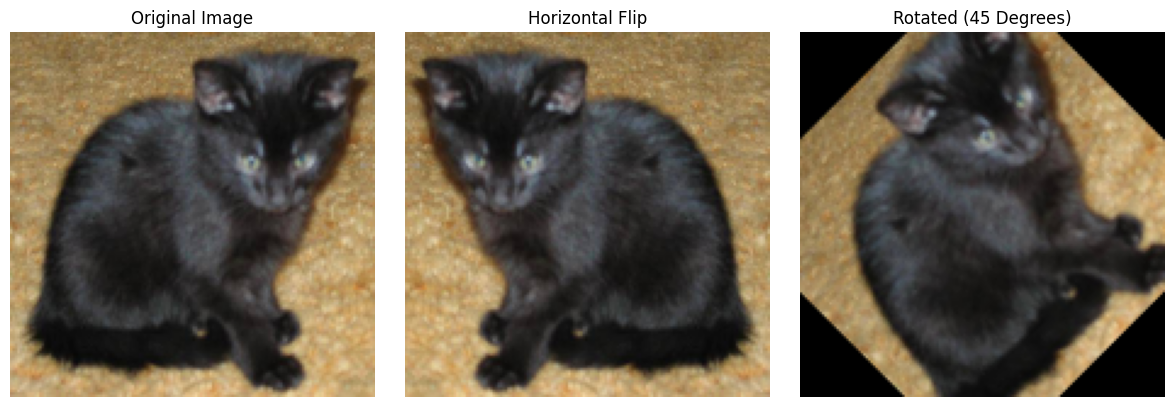

In [12]:

import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

dataset_path = "/content/train"
sample_image_name = os.listdir(dataset_path)[2] # Chose the 3rd image
sample_image_path = os.path.join(dataset_path, sample_image_name)


#  Geometric Transformations ---

#  read the Image, convert to RGB , resize it
img_aug = cv2.imread(sample_image_path)
img_aug = cv2.cvtColor(img_aug, cv2.COLOR_BGR2RGB)
img_aug = cv2.resize(img_aug, (150, 150))

# 1. Horizontal Flip
flipped_img = cv2.flip(img_aug, 1) # 1 means horizontal flip

# 2. Rotation (Rotate by 45 degrees)
center = (img_aug.shape[1]//2, img_aug.shape[0]//2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(img_aug, rotation_matrix, (img_aug.shape[1], img_aug.shape[0]))

# EDA Visualization: Transformation Grid
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_aug)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(flipped_img)
axes[1].set_title('Horizontal Flip')
axes[1].axis('off')

axes[2].imshow(rotated_img)
axes[2].set_title('Rotated (45 Degrees)')
axes[2].axis('off')

plt.tight_layout()
plt.show()